In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
df = pd.read_csv('upi_data_raw.csv')

In [3]:
df

,Month,Year,Volume_Cr,Value_LakhCr,Active_Banks,Registered_Apps
0,Jan,2017,2.5,0.04,30,5
1,Feb,2017,2.7,0.04,32,5
2,Mar,2017,3.3,0.06,35,5
3,Apr,2017,3.9,0.07,38,6
4,May,2017,4.5,0.08,40,6
...,...,...,...,...,...,...
110,Nov,2022,731.0,11.90,199,75
111,Apr,2023,899.0,14.07,214,81
112,Month,Year,Volume_Cr,Value_LakhCr,Active_Banks,Registered_Apps
113,Jan,2018,10.0,0.19,57,14


In [16]:
df.shape

(115, 6)

In [17]:
df.dtypes

Month              object
Year               object
Volume_Cr          object
Value_LakhCr       object
Active_Banks       object
Registered_Apps    object
dtype: object

In [19]:
df.head(5)

,Month,Year,Volume_Cr,Value_LakhCr,Active_Banks,Registered_Apps
0,Jan,2017,2.5,0.04,30,5
1,Feb,2017,2.7,0.04,32,5
2,Mar,2017,3.3,0.06,35,5
3,Apr,2017,3.9,0.07,38,6
4,May,2017,4.5,0.08,40,6


In [7]:
df.isnull().sum()


Month              0
Year               0
Volume_Cr          2
Value_LakhCr       1
Active_Banks       0
Registered_Apps    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(12)

In [14]:
df['Month'].unique()

array(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec', 'jan', 'Month'], dtype=object)

In [13]:
df['Volume_Cr'].sort_values(ascending=False).head(5)

112    Volume_Cr
78         996.0
31          98.0
32          96.0
107         96.0
Name: Volume_Cr, dtype: object

In [21]:
df = df[df['Volume_Cr'] != 'Volume_Cr']
df

,Month,Year,Volume_Cr,Value_LakhCr,Active_Banks,Registered_Apps
0,Jan,2017,2.5,0.04,30,5
1,Feb,2017,2.7,0.04,32,5
2,Mar,2017,3.3,0.06,35,5
3,Apr,2017,3.9,0.07,38,6
4,May,2017,4.5,0.08,40,6
...,...,...,...,...,...,...
109,Aug,2021,355.0,6.39,154,60
110,Nov,2022,731.0,11.90,199,75
111,Apr,2023,899.0,14.07,214,81
113,Jan,2018,10.0,0.19,57,14


In [22]:
df['Volume_Cr'] = df['Volume_Cr'].astype(float)
df['Value_LakhCr'] = df['Value_LakhCr'].astype(float)
df['Year'] = df['Year'].astype(int)

In [25]:
df.dtypes

Month               object
Year                 int64
Volume_Cr          float64
Value_LakhCr       float64
Active_Banks        object
Registered_Apps     object
dtype: object

In [27]:
df = df.drop_duplicates()

In [28]:
df.shape

(102, 6)

In [29]:
df['Volume_Cr'] = df['Volume_Cr'].interpolate()

In [30]:
df['Value_LakhCr'] = df['Value_LakhCr'].interpolate()

In [31]:
df = df[df['Month'] != 'Month']
df['Month'] = df['Month'].str.capitalize()
df['Month'].unique()

array(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec'], dtype=object)

In [32]:
df.describe()

,Year,Volume_Cr,Value_LakhCr
count,102.000000,102.000000,102.00000
mean,2020.764706,590.396078,8.17250
std,2.474329,814.382571,8.13738
min,2017.000000,2.500000,0.04000
25%,2019.000000,73.750000,1.16250
50%,2021.000000,259.500000,4.92000
75%,2023.000000,934.500000,14.58000
max,2025.000000,6280.000000,26.19000


In [33]:
df.loc[df['Volume_Cr'] == 6280.0, 'Volume_Cr'] = 628.0
df['Volume_Cr'].max()

2001.0

In [34]:
df.isnull().sum().sum(), df.duplicated().sum(), df.shape

(np.int64(0), np.int64(0), (102, 6))

In [35]:
df.head(3)

,Month,Year,Volume_Cr,Value_LakhCr,Active_Banks,Registered_Apps
0,Jan,2017,2.5,0.04,30,5
1,Feb,2017,2.7,0.04,32,5
2,Mar,2017,3.3,0.06,35,5


In [36]:
df['Avg_Ticket_Size_Rs'] = ((df['Value_LakhCr'] * 100000) / df['Volume_Cr']).round(0)
df[['Month','Year','Volume_Cr','Value_LakhCr','Avg_Ticket_Size_Rs']].head()

,Month,Year,Volume_Cr,Value_LakhCr,Avg_Ticket_Size_Rs
0,Jan,2017,2.5,0.04,1600.0
1,Feb,2017,2.7,0.04,1481.0
2,Mar,2017,3.3,0.06,1818.0
3,Apr,2017,3.9,0.07,1795.0
4,May,2017,4.5,0.08,1778.0


In [37]:
df['YoY_Growth'] = df.groupby('Month')['Volume_Cr'].pct_change() * 100
df[['Month','Year','Volume_Cr','YoY_Growth']].head(15)

,Month,Year,Volume_Cr,YoY_Growth
0,Jan,2017,2.5,NaN
1,Feb,2017,2.7,NaN
2,Mar,2017,3.3,NaN
3,Apr,2017,3.9,NaN
4,May,2017,4.5,NaN
5,Jun,2017,5.5,NaN
6,Jul,2017,7.0,NaN
7,Aug,2017,8.5,NaN
8,Sep,2017,9.5,NaN
9,Oct,2017,10.5,NaN


In [38]:
df['Date'] = pd.to_datetime(df['Month'] + ' ' + df['Year'].astype(str))
df[['Date','Volume_Cr','Value_LakhCr']].head()

,Date,Volume_Cr,Value_LakhCr
0,2017-01-01,2.5,0.04
1,2017-02-01,2.7,0.04
2,2017-03-01,3.3,0.06
3,2017-04-01,3.9,0.07
4,2017-05-01,4.5,0.08


In [39]:
df = df.sort_values('Date').reset_index(drop=True)
df[['Date','Volume_Cr','Value_LakhCr']].head()

,Date,Volume_Cr,Value_LakhCr
0,2017-01-01,2.5,0.04
1,2017-02-01,2.7,0.04
2,2017-03-01,3.3,0.06
3,2017-04-01,3.9,0.07
4,2017-05-01,4.5,0.08


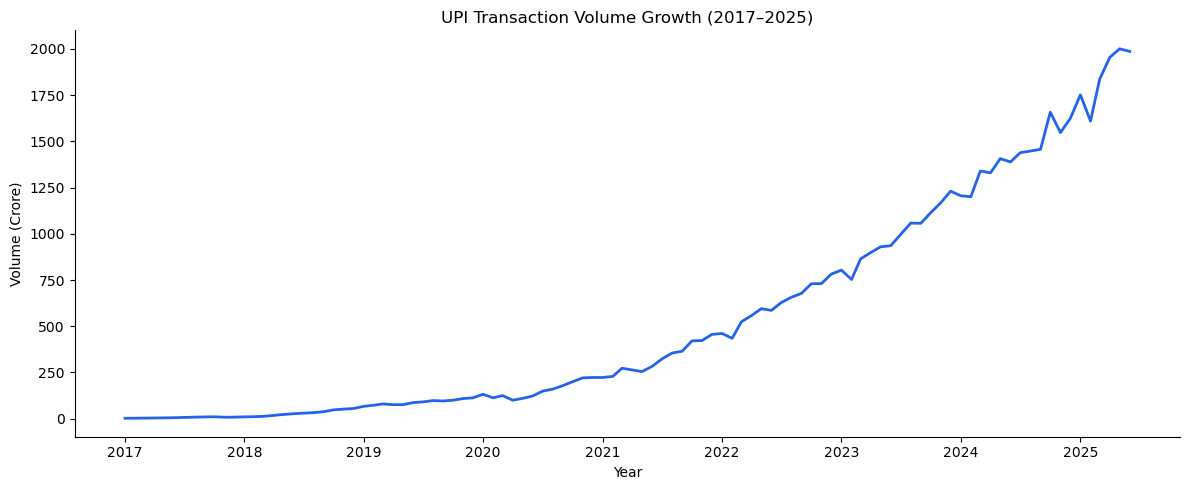

In [40]:
plt.plot(df['Date'], df['Volume_Cr'], color='#2563EB', linewidth=2)
plt.title('UPI Transaction Volume Growth (2017–2025)')
plt.xlabel('Year')
plt.ylabel('Volume (Crore)')
plt.tight_layout()
plt.show()

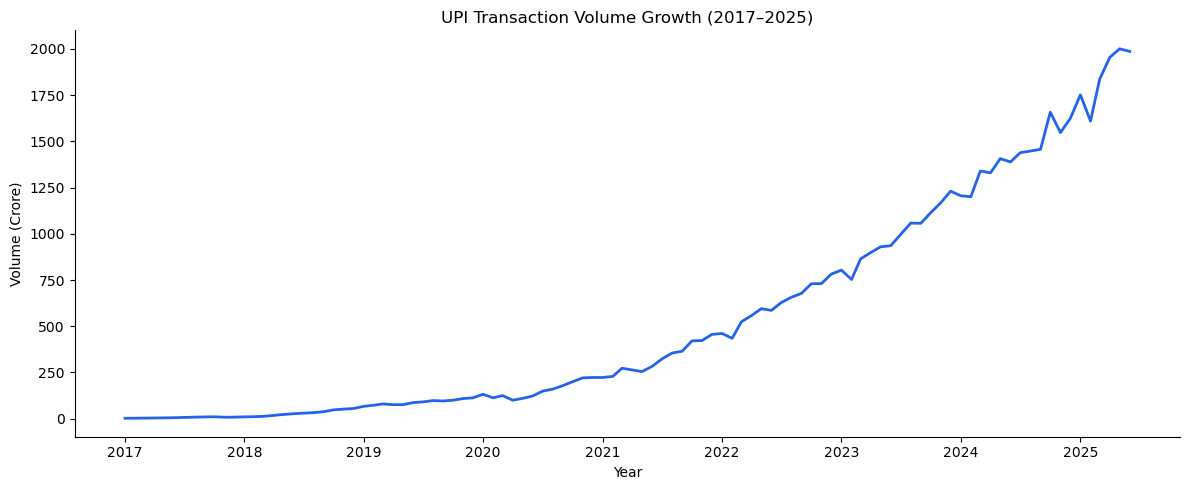

In [41]:
plt.plot(df['Date'], df['Volume_Cr'], color='#2563EB', linewidth=2)
plt.title('UPI Transaction Volume Growth (2017–2025)')
plt.xlabel('Year')
plt.ylabel('Volume (Crore)')
plt.tight_layout()
plt.show()

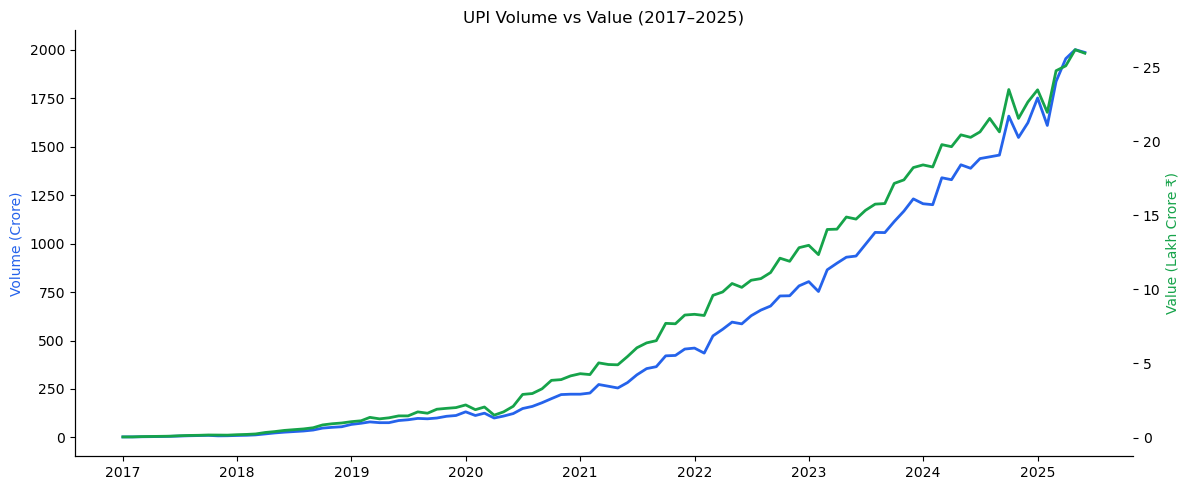

In [42]:
fig, ax1 = plt.subplots()
ax1.plot(df['Date'], df['Volume_Cr'], color='#2563EB', linewidth=2, label='Volume (Cr)')
ax1.set_ylabel('Volume (Crore)', color='#2563EB')

ax2 = ax1.twinx()
ax2.plot(df['Date'], df['Value_LakhCr'], color='#16A34A', linewidth=2, label='Value (Lakh Cr)')
ax2.set_ylabel('Value (Lakh Crore ₹)', color='#16A34A')

plt.title('UPI Volume vs Value (2017–2025)')
plt.tight_layout()
plt.show()

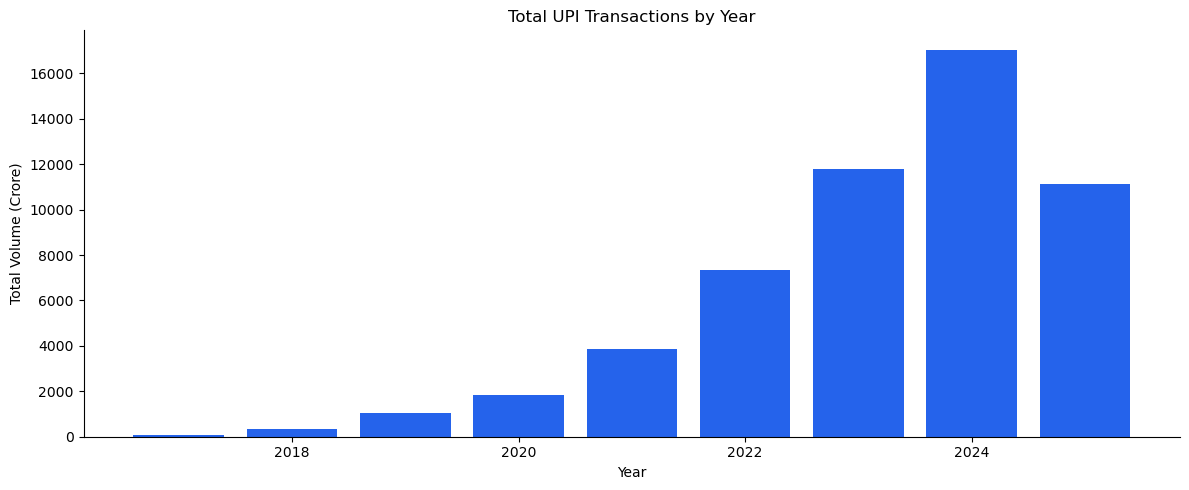

In [43]:
yearly = df.groupby('Year')['Volume_Cr'].sum().reset_index()
plt.bar(yearly['Year'], yearly['Volume_Cr'], color='#2563EB')
plt.title('Total UPI Transactions by Year')
plt.xlabel('Year')
plt.ylabel('Total Volume (Crore)')
plt.tight_layout()
plt.show()

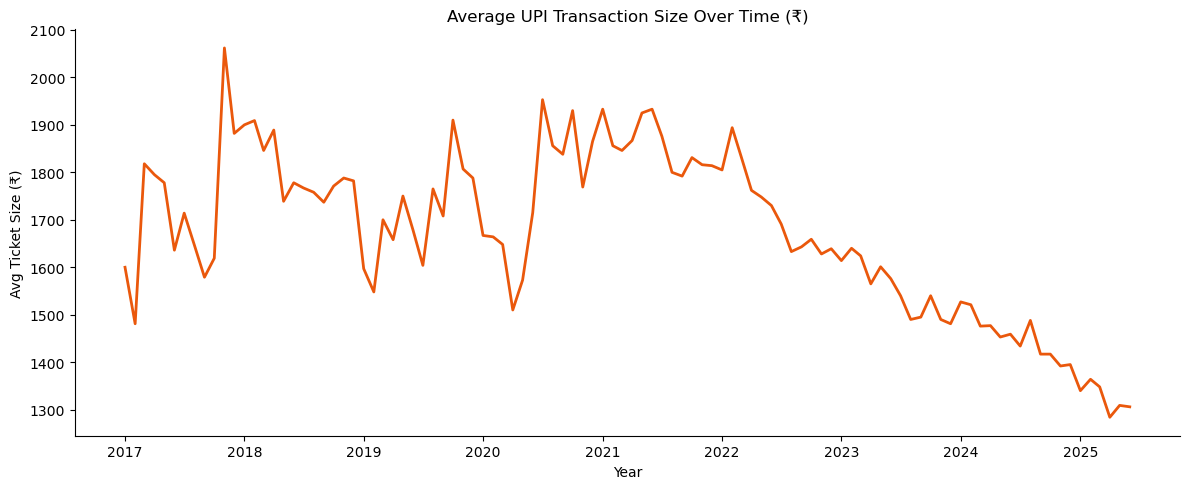

In [44]:
plt.plot(df['Date'], df['Avg_Ticket_Size_Rs'], color='#EA580C', linewidth=2)
plt.title('Average UPI Transaction Size Over Time (₹)')
plt.xlabel('Year')
plt.ylabel('Avg Ticket Size (₹)')
plt.tight_layout()
plt.show()

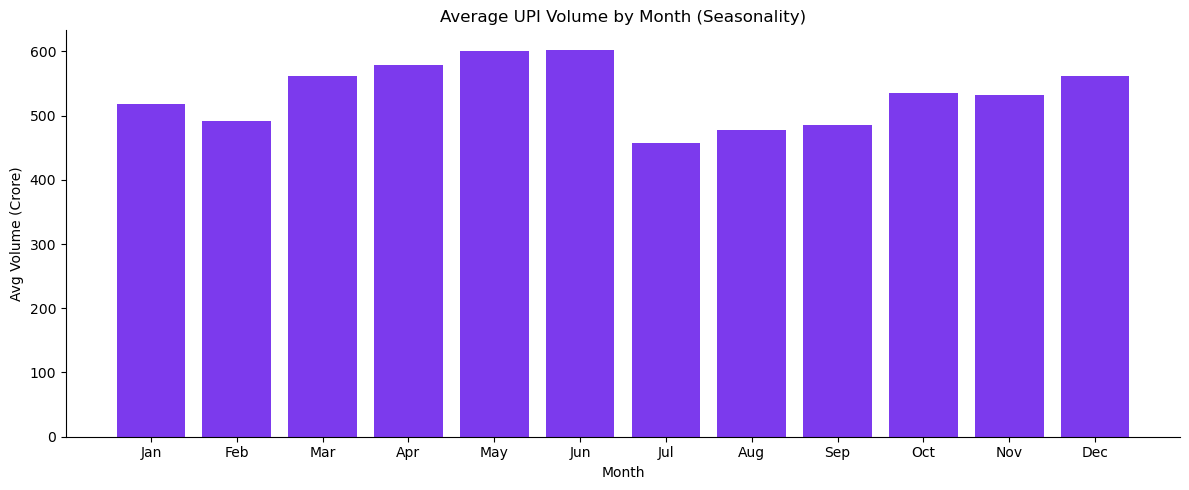

In [45]:
monthly_avg = df.groupby('Month')['Volume_Cr'].mean().reindex(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.bar(monthly_avg.index, monthly_avg.values, color='#7C3AED')
plt.title('Average UPI Volume by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Avg Volume (Crore)')
plt.tight_layout()
plt.show()

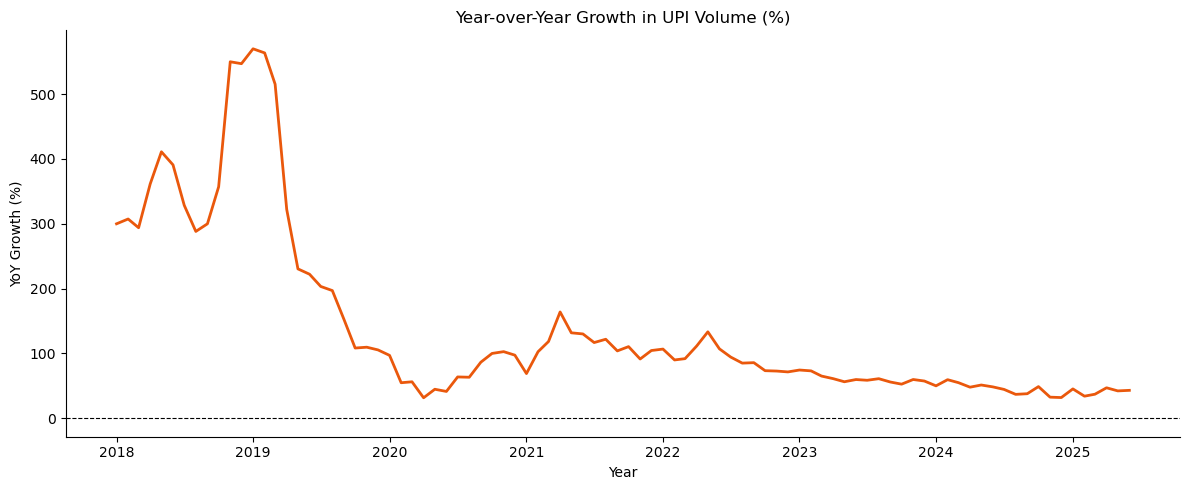

In [46]:
yoy = df.dropna(subset=['YoY_Growth'])
plt.plot(yoy['Date'], yoy['YoY_Growth'], color='#EA580C', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Year-over-Year Growth in UPI Volume (%)')
plt.xlabel('Year')
plt.ylabel('YoY Growth (%)')
plt.tight_layout()
plt.show()

In [47]:
yoy['YoY_Growth'].describe()

count     90.000000
mean     139.910021
std      135.845512
min       31.578947
25%       55.987279
50%       90.679523
75%      132.954545
max      570.000000
Name: YoY_Growth, dtype: float64

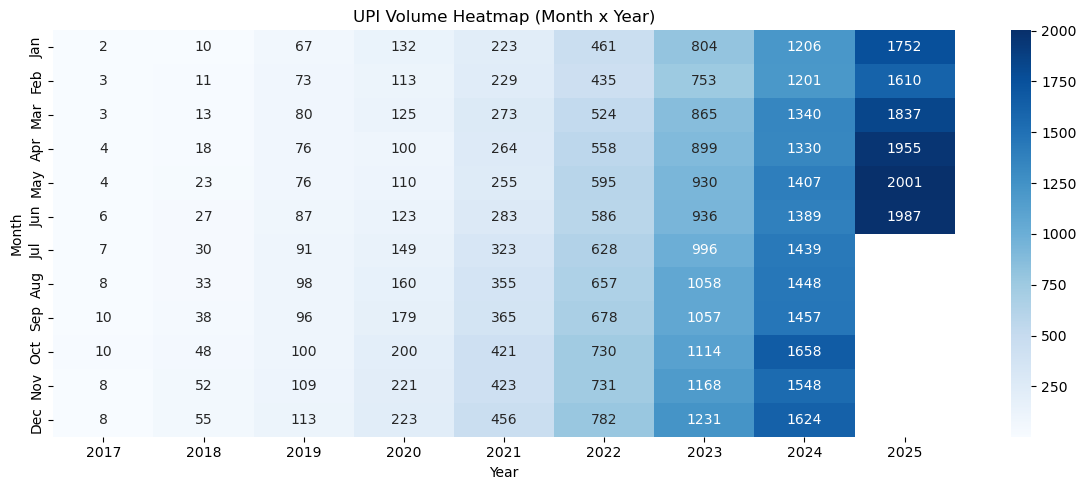

In [48]:
pivot = df.pivot_table(values='Volume_Cr', index='Month', columns='Year', aggfunc='sum')
pivot = pivot.reindex(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
import seaborn as sns
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title('UPI Volume Heatmap (Month x Year)')
plt.tight_layout()
plt.show()

In [50]:
df[['Volume_Cr', 'Value_LakhCr', 'Avg_Ticket_Size_Rs']].corr()

,Volume_Cr,Value_LakhCr,Avg_Ticket_Size_Rs
Volume_Cr,1.000000,0.994079,-0.782964
Value_LakhCr,0.994079,1.000000,-0.747191
Avg_Ticket_Size_Rs,-0.782964,-0.747191,1.000000


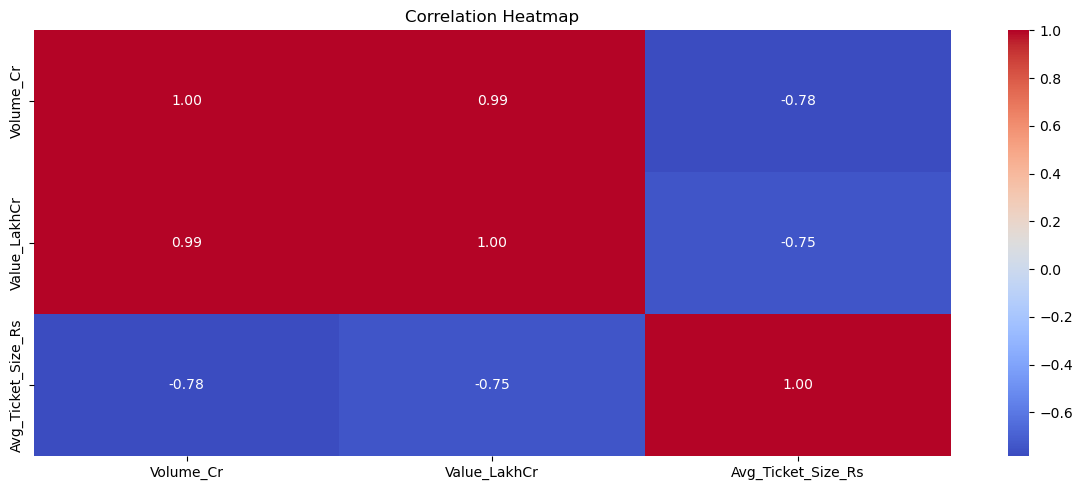

In [51]:
sns.heatmap(df[['Volume_Cr','Value_LakhCr','Avg_Ticket_Size_Rs']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [52]:
df.nlargest(5, 'Volume_Cr')[['Month','Year','Volume_Cr']]

,Month,Year,Volume_Cr
100,May,2025,2001.0
101,Jun,2025,1987.0
99,Apr,2025,1955.0
98,Mar,2025,1837.0
96,Jan,2025,1752.0


In [53]:
df.groupby('Year')['Volume_Cr'].sum().reset_index()

,Year,Volume_Cr
0,2017,74.4
1,2018,358.0
2,2019,1066.0
3,2020,1835.0
4,2021,3870.0
5,2022,7365.0
6,2023,11811.0
7,2024,17047.0
8,2025,11142.0


In [64]:
df.to_csv('upi_data_clean.csv', index=False)

In [55]:
import sqlite3
conn = sqlite3.connect('upi.db')

In [56]:
df.to_sql('upi_transactions', conn, if_exists='replace', index=False)

102

In [57]:
pd.read_sql('SELECT * FROM upi_transactions LIMIT 5', conn)

,Month,Year,Volume_Cr,Value_LakhCr,Active_Banks,Registered_Apps,Avg_Ticket_Size_Rs,YoY_Growth,Date
0,Jan,2017,2.5,0.04,30,5,1600.0,None,2017-01-01 00:00:00
1,Feb,2017,2.7,0.04,32,5,1481.0,None,2017-02-01 00:00:00
2,Mar,2017,3.3,0.06,35,5,1818.0,None,2017-03-01 00:00:00
3,Apr,2017,3.9,0.07,38,6,1795.0,None,2017-04-01 00:00:00
4,May,2017,4.5,0.08,40,6,1778.0,None,2017-05-01 00:00:00


In [58]:
pd.read_sql('''
SELECT Year, 
       ROUND(SUM(Volume_Cr), 0) as Total_Volume_Cr,
       ROUND(SUM(Value_LakhCr), 2) as Total_Value_LakhCr
FROM upi_transactions
GROUP BY Year
ORDER BY Year
''', conn)

,Year,Total_Volume_Cr,Total_Value_LakhCr
0,2017,74.0,1.29
1,2018,358.0,6.39
2,2019,1066.0,18.34
3,2020,1835.0,32.59
4,2021,3870.0,71.56
5,2022,7365.0,125.85
6,2023,11811.0,182.78
7,2024,17047.0,247.35
8,2025,11142.0,147.45


In [59]:
pd.read_sql('''
SELECT Year, Month, MAX(Volume_Cr) as Peak_Volume
FROM upi_transactions
GROUP BY Year
ORDER BY Year
''', conn)

,Year,Month,Peak_Volume
0,2017,Oct,10.5
1,2018,Dec,55.0
2,2019,Dec,113.0
3,2020,Dec,223.0
4,2021,Dec,456.0
5,2022,Dec,782.0
6,2023,Dec,1231.0
7,2024,Oct,1658.0
8,2025,May,2001.0


In [60]:
pd.read_sql('''
SELECT Year,
       ROUND(SUM(Volume_Cr), 0) as Total_Volume,
       ROUND(SUM(Volume_Cr) * 100.0 / LAG(SUM(Volume_Cr)) OVER (ORDER BY Year) - 100, 1) as YoY_Growth_Pct
FROM upi_transactions
GROUP BY Year
ORDER BY Year
''', conn)

,Year,Total_Volume,YoY_Growth_Pct
0,2017,74.0,NaN
1,2018,358.0,381.2
2,2019,1066.0,197.8
3,2020,1835.0,72.1
4,2021,3870.0,110.9
5,2022,7365.0,90.3
6,2023,11811.0,60.4
7,2024,17047.0,44.3
8,2025,11142.0,-34.6


In [61]:
pd.read_sql('''
SELECT Month,
       ROUND(AVG(Volume_Cr), 0) as Avg_Volume,
       COUNT(*) as Years_Present
FROM upi_transactions
GROUP BY Month
ORDER BY Avg_Volume DESC
''', conn)

,Month,Avg_Volume,Years_Present
0,Jun,603.0,9
1,May,600.0,9
2,Apr,578.0,9
3,Mar,562.0,9
4,Dec,562.0,8
5,Oct,535.0,8
6,Nov,533.0,8
7,Jan,518.0,9
8,Feb,492.0,9
9,Sep,485.0,8


In [62]:
pd.read_sql('''
SELECT Month, Year, Volume_Cr
FROM upi_transactions
WHERE Volume_Cr > (SELECT AVG(Volume_Cr) FROM upi_transactions)
ORDER BY Volume_Cr DESC
''', conn)

,Month,Year,Volume_Cr
0,May,2025,2001.0
1,Jun,2025,1987.0
2,Apr,2025,1955.0
3,Mar,2025,1837.0
4,Jan,2025,1752.0
5,Oct,2024,1658.0
6,Dec,2024,1624.0
7,Feb,2025,1610.0
8,Nov,2024,1548.0
9,Sep,2024,1457.0


In [63]:
pd.read_sql('''
SELECT Month, Year, Volume_Cr,
       ROUND(AVG(Volume_Cr) OVER (ORDER BY Year, Month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 0) as Rolling_3M_Avg
FROM upi_transactions
ORDER BY Year, Month
''', conn)

,Month,Year,Volume_Cr,Rolling_3M_Avg
0,Apr,2017,3.9,4.0
1,Aug,2017,8.5,6.0
2,Dec,2017,8.5,7.0
3,Feb,2017,2.7,7.0
4,Jan,2017,2.5,5.0
...,...,...,...,...
97,Feb,2025,1610.0,1674.0
98,Jan,2025,1752.0,1772.0
99,Jun,2025,1987.0,1783.0
100,Mar,2025,1837.0,1859.0
